In [ ]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

# Classifier Libraries
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
import collections


# Other Libraries
from sklearn.model_selection import train_test_split
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE, RandomOverSampler
from imblearn.under_sampling import NearMiss, RandomUnderSampler, TomekLinks
from imblearn.combine import SMOTETomek
from imblearn.metrics import classification_report_imbalanced
from sklearn.metrics import ConfusionMatrixDisplay, RocCurveDisplay, PrecisionRecallDisplay
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, accuracy_score, classification_report, confusion_matrix
from collections import Counter
from sklearn.model_selection import StratifiedKFold, GridSearchCV, learning_curve
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
import umap

c:\Users\User\anaconda3\envs\kiet05\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# I. Overall

In [2]:
df = pd.read_csv('creditcard.csv')
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [3]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,...,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


In [4]:
df.isnull().sum()

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

In [5]:
df_fraud = df[df['Class'] == 1]
df_non_fraud = df[df['Class'] == 0]
no_fraud_pct = (len(df_non_fraud) / len(df)) * 100
fraud_pct = (len(df_fraud) / len(df)) * 100

print('No Frauds', round(no_fraud_pct, 2), '% of the dataset')
print('Frauds', round(fraud_pct,2), '% of the dataset')

No Frauds 99.83 % of the dataset
Frauds 0.17 % of the dataset


Text(0.5, 1.0, 'Class Distributions \n (0: No Fraud || 1: Fraud)')

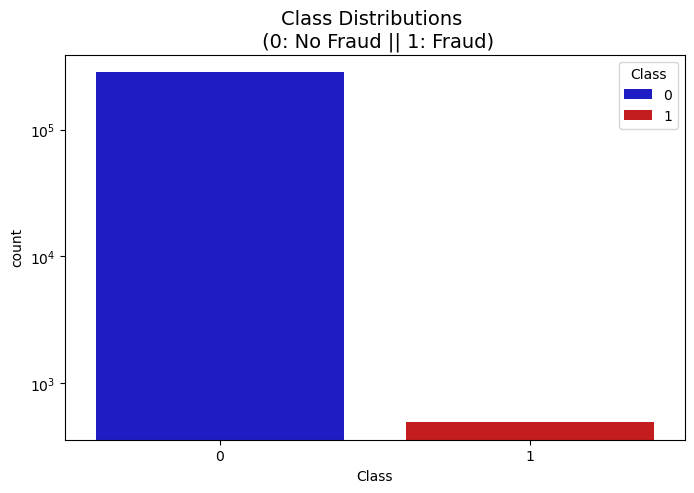

In [6]:
colors = ["#0101DF", "#DF0101"]
fig, ax = plt.subplots(1, 1, figsize = (8, 5))
# Categorical plot: count of observations in each category(x): Fraud/Not Fraud
sns.countplot(x='Class', data=df, palette=colors, hue = 'Class', ax = ax)
ax.set_yscale('log')
ax.minorticks_off()
plt.title('Class Distributions \n (0: No Fraud || 1: Fraud)', fontsize=14)

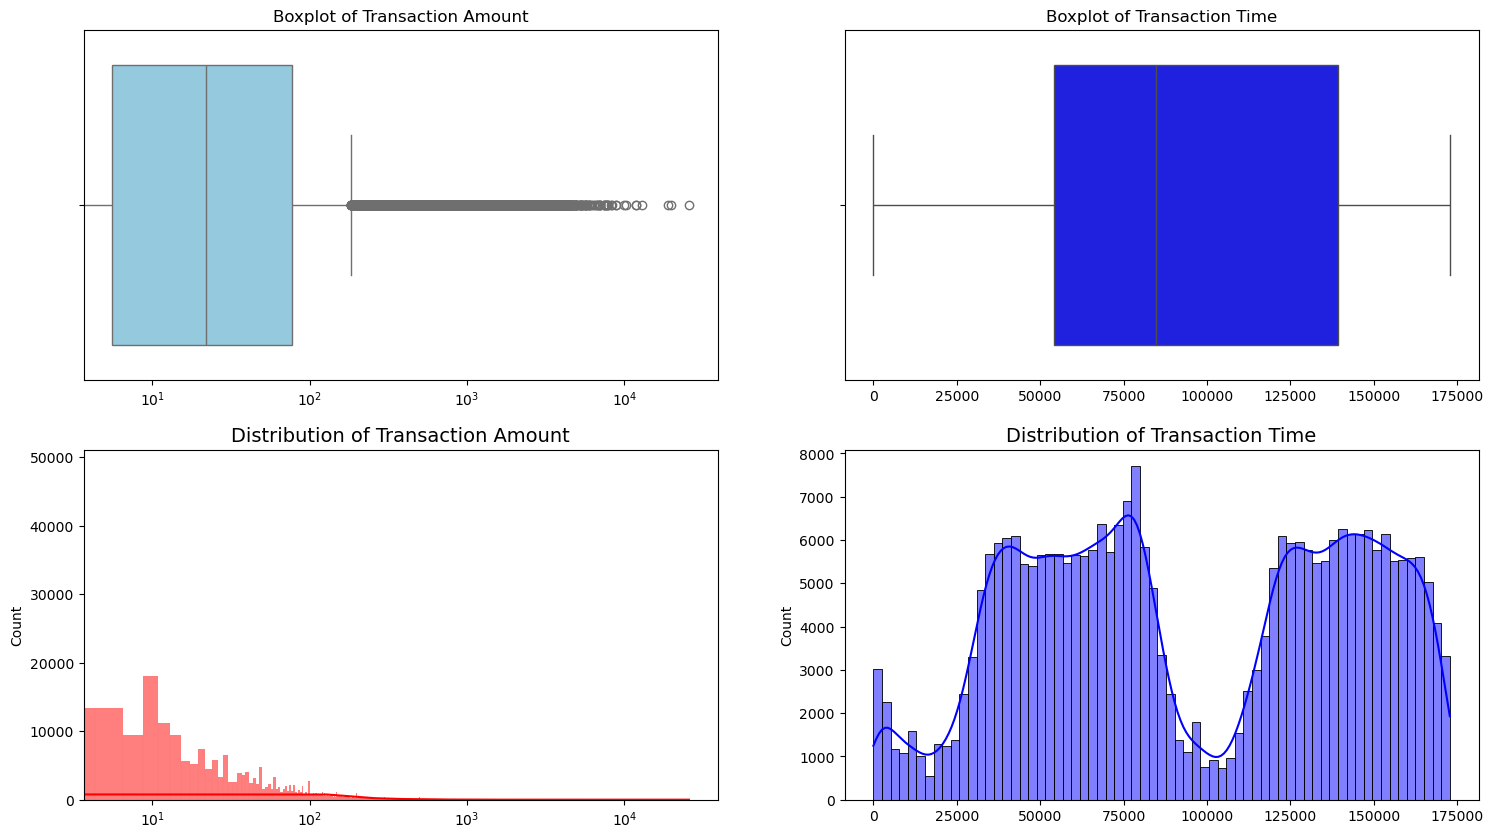

In [8]:
fig, ax = plt.subplots(2, 2, figsize=(18,10))

amount_val = df['Amount'].values
time_val = df['Time'].values

sns.boxplot(x = amount_val, ax = ax[0][0], color='skyblue')
ax[0][0].set_title("Boxplot of Transaction Amount")
ax[0][0].set_xscale('log')
ax[0][0].minorticks_off()

sns.histplot(amount_val, ax=ax[1][0], color='r', kde=True, bins = 'auto')
ax[1][0].set_title('Distribution of Transaction Amount', fontsize=14)
ax[1][0].set_xscale('log')
ax[1][0].set_xlim(ax[0][0].get_xlim()) 
ax[1][0].minorticks_off()

sns.boxplot(x=time_val, ax=ax[0][1], color='blue')
ax[0][1].set_title("Boxplot of Transaction Time")


sns.histplot(time_val, ax=ax[1][1], color='b',kde=True, bins = 'auto')
ax[1][1].set_title('Distribution of Transaction Time', fontsize=14)
ax[1][1].set_xlim(ax[0][1].get_xlim())


plt.show()

# II. Preprocessing

## 1. Scaling "Amount" and "Time"

In [ ]:
# Since most of our data has already been scaled we should scale the columns that are left to scale (Amount and Time)
from sklearn.preprocessing import StandardScaler, RobustScaler

# RobustScaler is less prone to outliers.

std_scaler = StandardScaler() # x_scaled = (x - mean)/sd, for normal distribution, no outliers
rob_scaler = RobustScaler() # x_scaled = (x-median)/(Q3-Q1) with Q3 is point of 75% data, Q1 is point of 25% data
                            # for skewed data, data with many outliers

scaled_amount = rob_scaler.fit_transform(df['Amount'].values.reshape(-1,1))                                    
scaled_time = rob_scaler.fit_transform(df['Time'].values.reshape(-1,1))
# we need to reshape becasue df.values return shape like (n, ); but sklearn scaler need 2D input
# so we reshape it to (n, 1)

df.drop(['Time','Amount'], axis=1, inplace=True)
df.insert(0, 'scaled_amount', scaled_amount)
df.insert(1, 'scaled_time', scaled_time)
df

,scaled_amount,scaled_time,V1,V2,V3,V4,V5,V6,V7,V8,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Class
0,1.783274,-0.994983,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,...,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,0
1,-0.269825,-0.994983,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,...,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,0
2,4.983721,-0.994972,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,...,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,0
3,1.418291,-0.994972,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,...,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,0
4,0.670579,-0.994960,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,...,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
284802,-0.296653,1.034951,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,...,1.475829,0.213454,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,0
284803,0.038986,1.034963,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,...,0.059616,0.214205,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,0
284804,0.641096,1.034975,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,...,0.001396,0.232045,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,0
284805,-0.167680,1.034975,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,...,0.127434,0.265245,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,0


## 2. Outliers

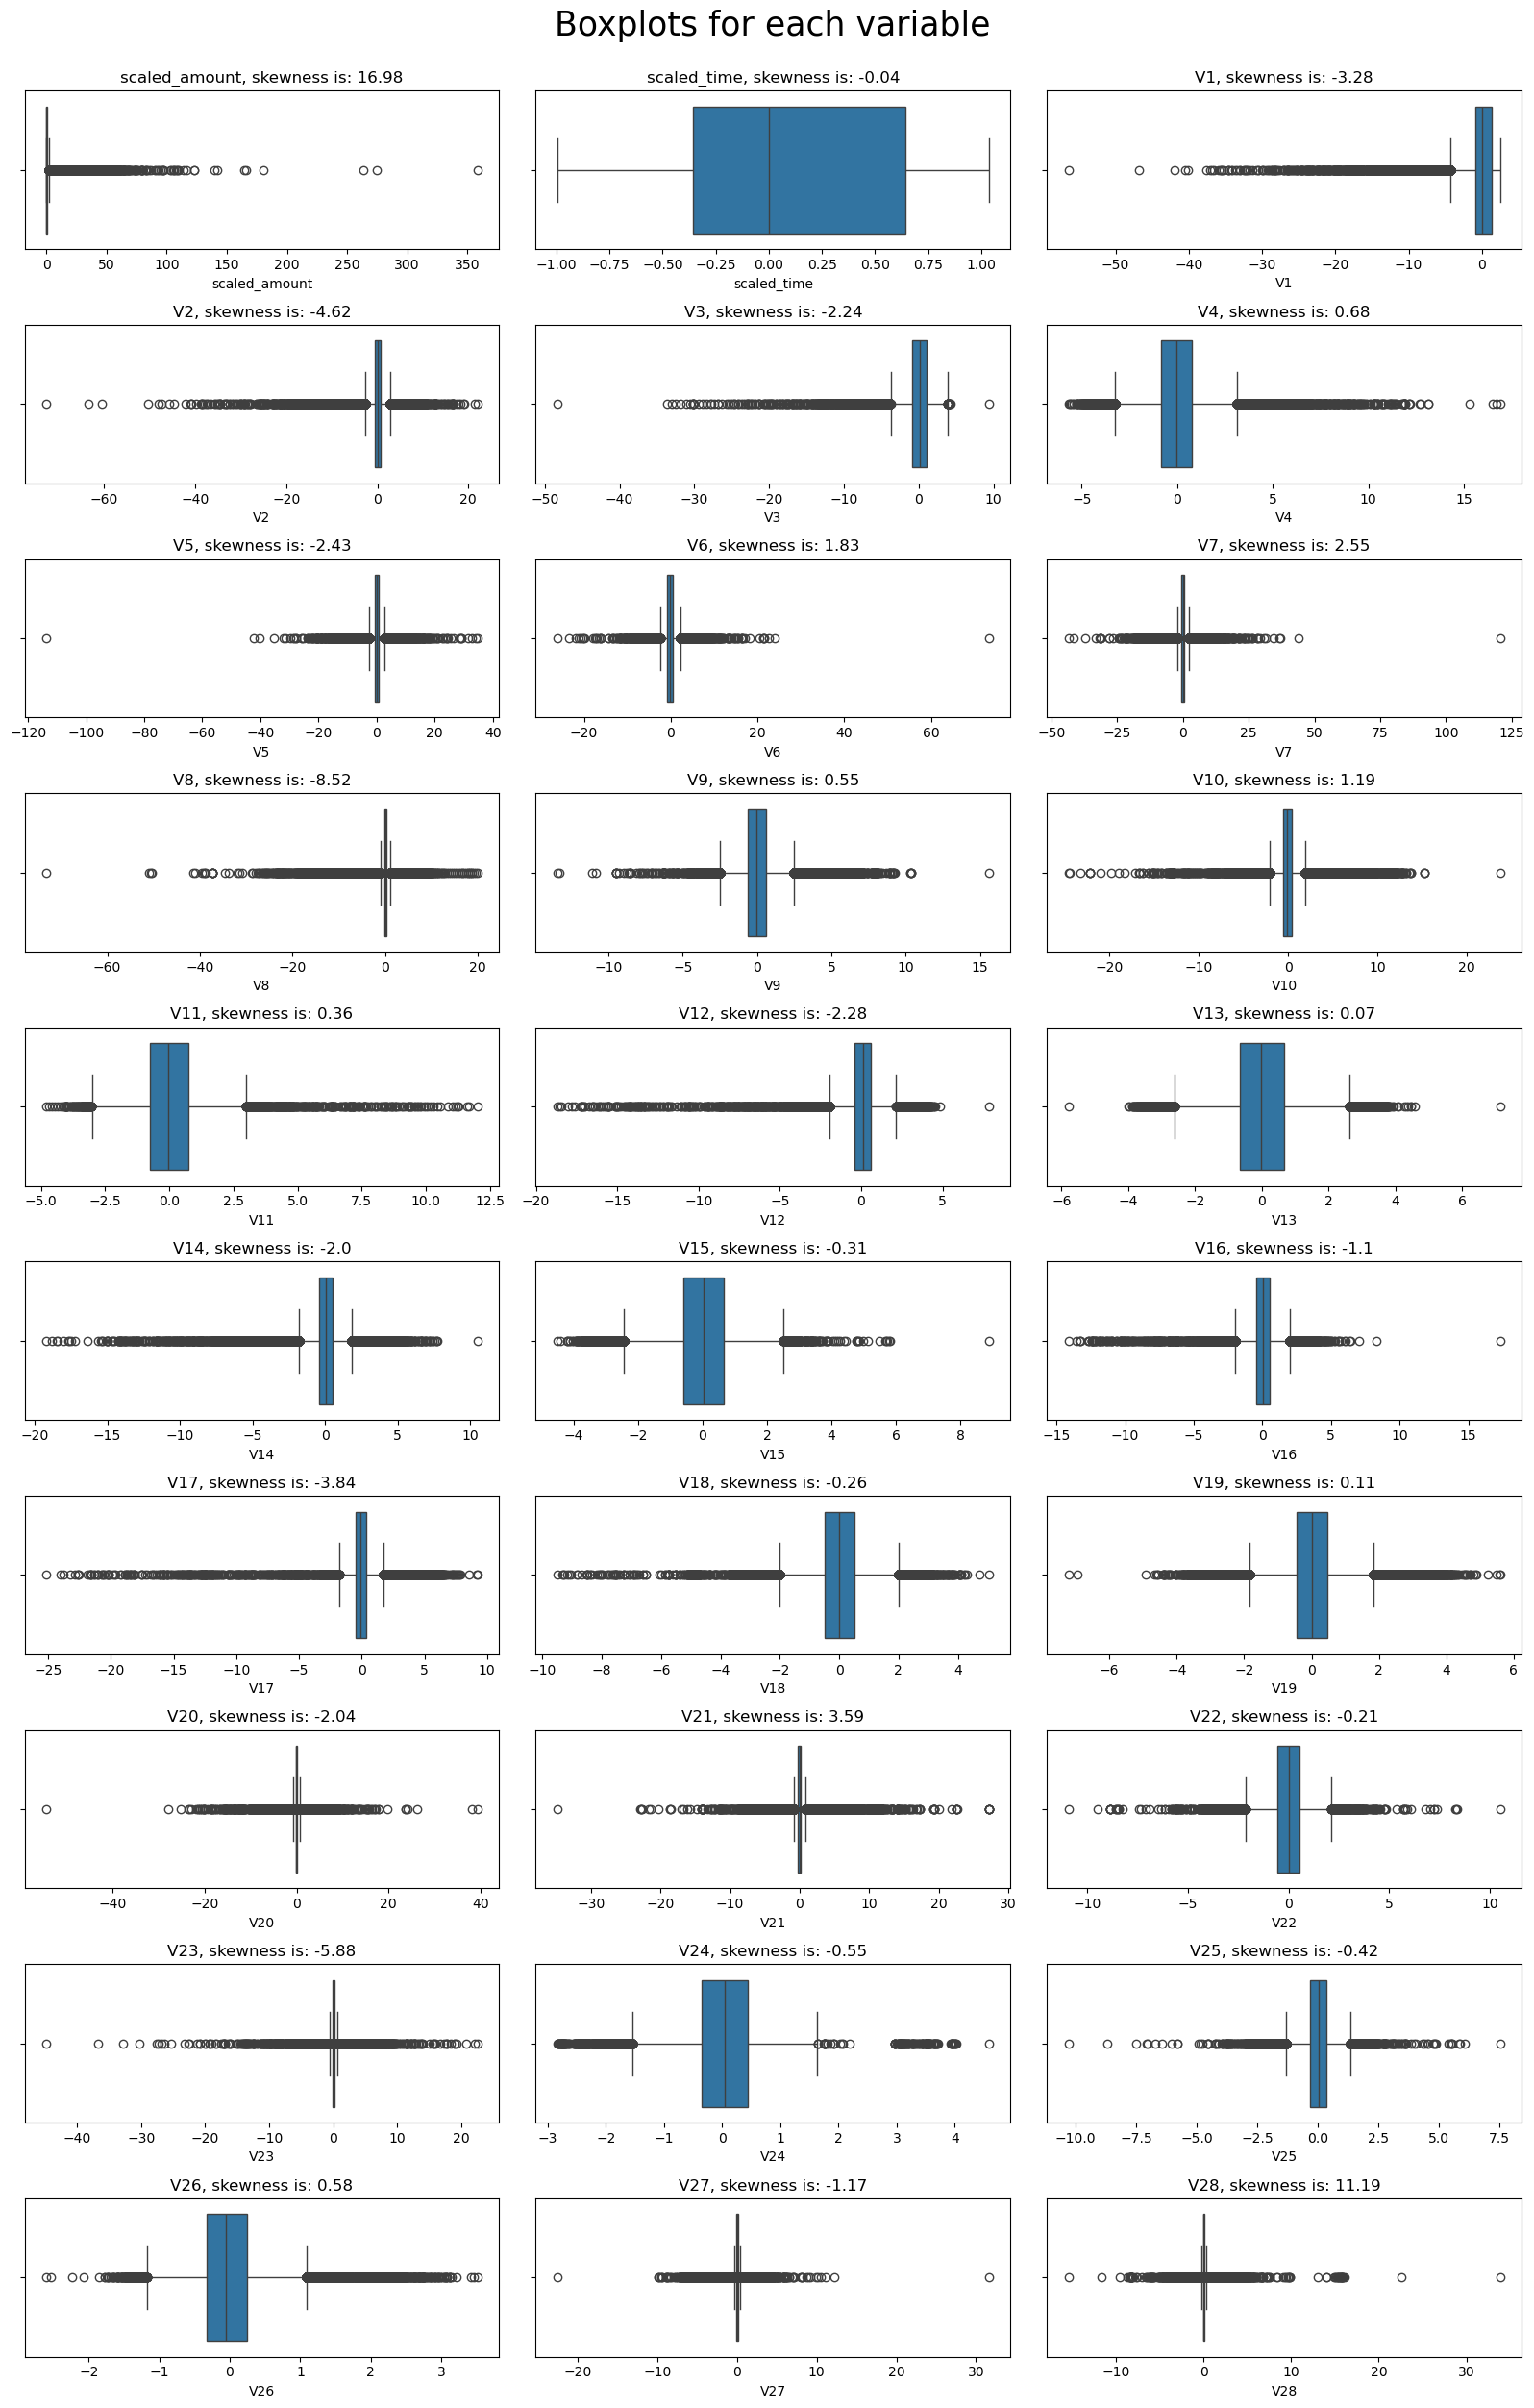

In [ ]:
numeric_columns = (list(df.columns[:30]))
def boxplots_custom(dataset, columns_list, rows, cols, suptitle):
    fig, axs = plt.subplots(rows, cols, sharey=True, figsize=(16,25))
    fig.suptitle(suptitle,y=1, size=25)
    axs = axs.flatten()
    for i, data in enumerate(columns_list):
        sns.boxplot(data=dataset[data], orient='h', ax=axs[i])
        axs[i].set_title(data + ', skewness is: '+str(round(dataset[data].skew(axis = 0, skipna = True),2)))
        
boxplots_custom(dataset=df, columns_list=numeric_columns, rows=10, cols=3, suptitle='Boxplots for each variable')
plt.tight_layout()

## 3. Remove outliers

In [ ]:
def IQR_method (df,n,features):
    """
    Takes a dataframe and returns an index list corresponding to the observations 
    containing more than n outliers according to the Tukey IQR method.
    """
    outlier_list = []
    
    for column in features:
        # 1st quartile (25%)
        q1 = np.percentile(df[column], 25)
        # 3rd quartile (75%)
        q3 = np.percentile(df[column],75)
        # Interquartile range (IQR)
        iqr = q3 - q1
        # outlier step
        outlier_step = 1.5 * iqr
        # Determining a list of indices of outliers
        outlier_list_column = df[(df[column] < q1 - outlier_step) | (df[column] > q3 + outlier_step )].index
        # appending the list of outliers 
        outlier_list.extend(outlier_list_column)
        
    # selecting observations containing more than x outliers
    outlier_list = Counter(outlier_list)        
    multiple_outliers = list( k for k, v in outlier_list.items() if v > n )
    
    # Calculate the number of records below and above lower and above bound value respectively
    out1 = df[df[column] < q1 - outlier_step]
    out2 = df[df[column] > q3 + outlier_step]
    
    print('Total number of deleted outliers is:', out1.shape[0]+out2.shape[0])
    
    return multiple_outliers

In [ ]:
# detecting outliers
Outliers_IQR = IQR_method(df,1,numeric_columns)

# dropping outliers
df_out = df.drop(Outliers_IQR, axis = 0).reset_index(drop=True)

Total number of deleted outliers is: 30342


# III. Sampling methods

In [ ]:
blue_patch = mpatches.Patch(color='#0A0AFF', label='No Fraud')
red_patch = mpatches.Patch(color='#AF0000', label='Fraud')

In [ ]:
X = df[numeric_columns].copy()
y = df["Class"].copy()

In [ ]:
def create_resampled_folds(X, y, sampler):
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    train_sets = []
    test_sets = []

    for train_idx, test_idx in skf.split(X, y):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

        X_res, y_res = sampler.fit_resample(X_train, y_train)

        train_sets.append((X_res, y_res))
        test_sets.append((X_test, y_test))

    return train_sets, test_sets

## 1. Random under-sampling

In [ ]:
rus_train, rus_test = create_resampled_folds(X, y, RandomUnderSampler(sampling_strategy=0.5))

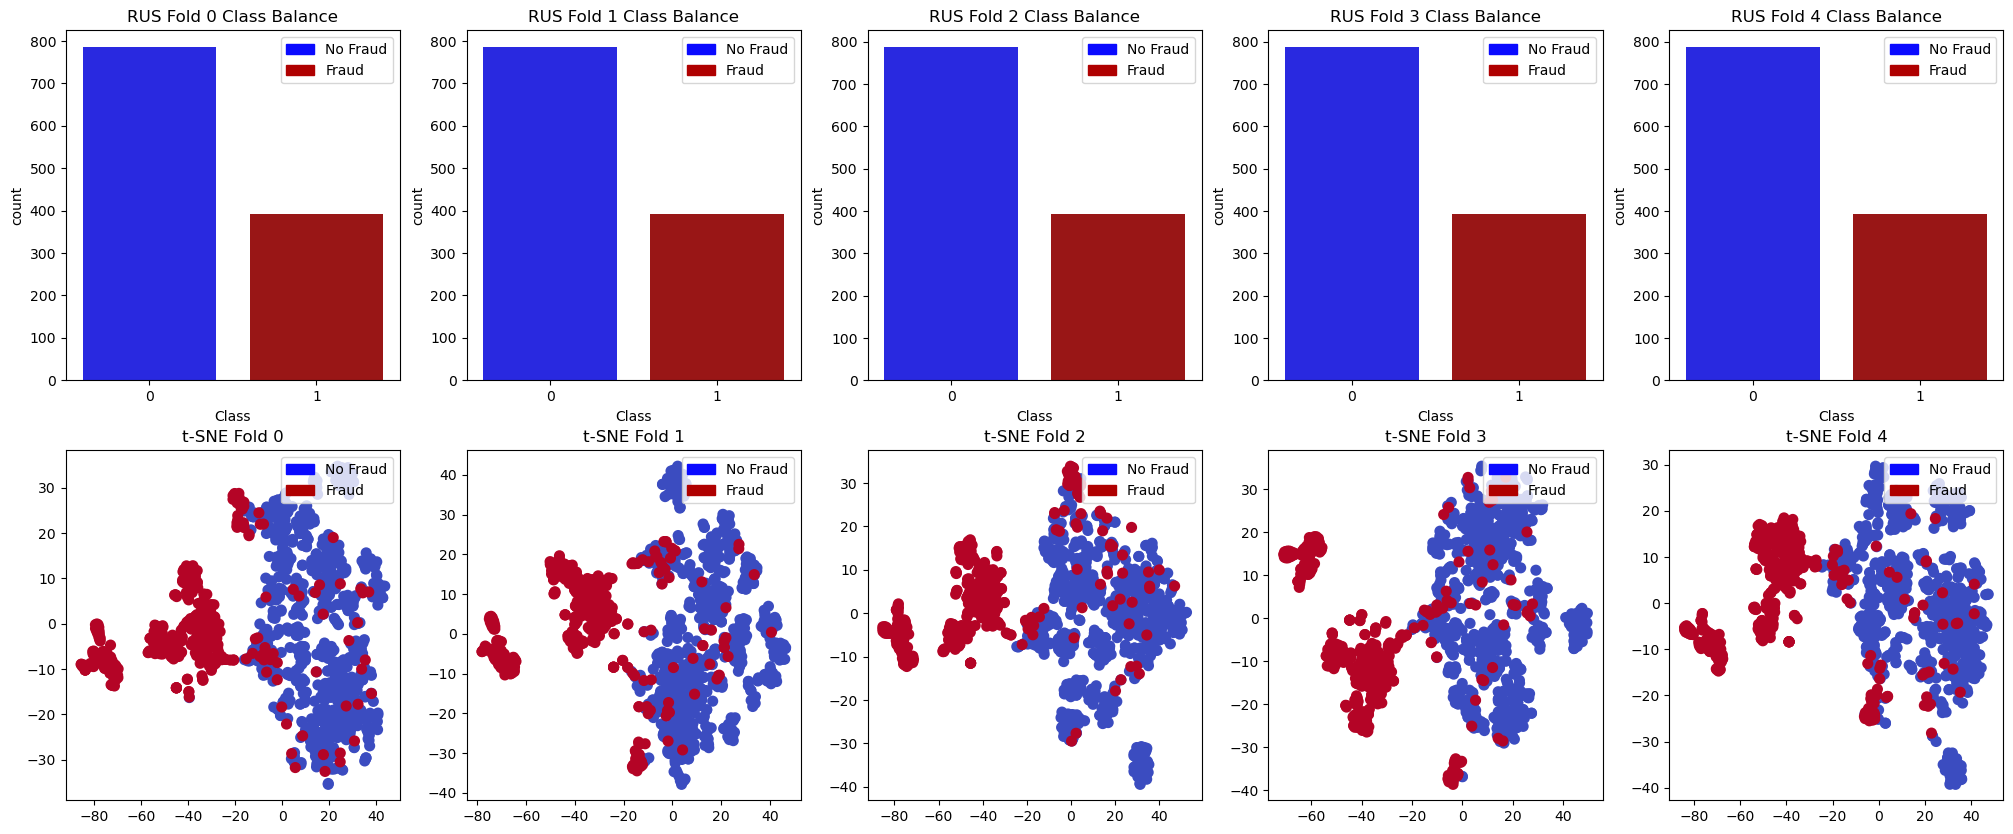

In [ ]:
f, ax = plt.subplots(2, 5, figsize=(25,10))
for i, (X_res, y_res) in enumerate(rus_train):
    sns.countplot(x = y_res, ax = ax[0][i], palette=['#0A0AFF', '#AF0000'], hue = y_res)
    ax[0][i].set_title(f"RUS Fold {i} Class Balance")
    ax[0][i].legend(handles=[blue_patch, red_patch])
    X_reduced = TSNE(n_components=2, random_state=42, n_jobs=1).fit_transform(X_res)
    ax[1][i].scatter(X_reduced[:,0], X_reduced[:,1], c=y_res, cmap='coolwarm', linewidths=2)
    ax[1][i].set_title(f"t-SNE Fold {i}")
    ax[1][i].legend(handles=[blue_patch, red_patch], loc = 'upper right')

## 2. NearMiss under-sampling

In [ ]:
nearmiss_train, nearmiss_test = create_resampled_folds(X, y, NearMiss(sampling_strategy=0.5))

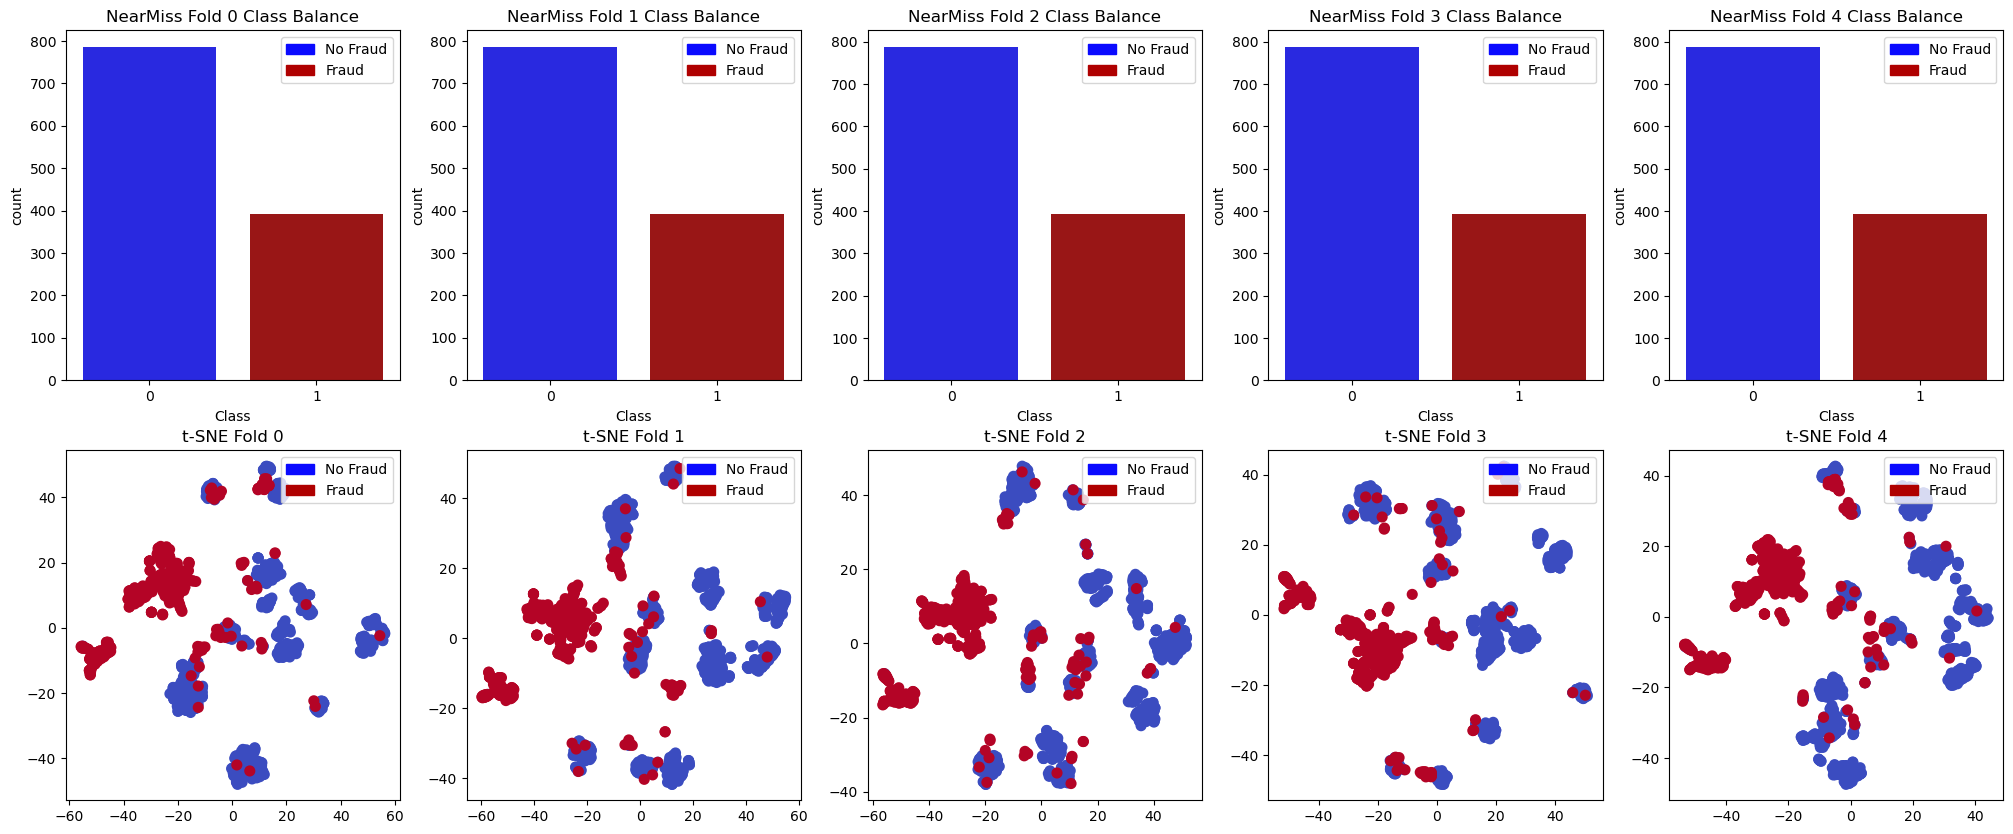

In [ ]:
f, ax = plt.subplots(2, 5, figsize=(25,10))
for i, (X_res, y_res) in enumerate(nearmiss_train):
    sns.countplot(x = y_res, ax = ax[0][i], palette=['#0A0AFF', '#AF0000'], hue = y_res)
    ax[0][i].set_title(f"NearMiss Fold {i} Class Balance")
    ax[0][i].legend(handles=[blue_patch, red_patch])
    X_reduced = TSNE(n_components=2, random_state=42, n_jobs=1).fit_transform(X_res)
    ax[1][i].scatter(X_reduced[:,0], X_reduced[:,1], c=y_res, cmap='coolwarm', linewidths=2)
    ax[1][i].set_title(f"t-SNE Fold {i}")
    ax[1][i].legend(handles=[blue_patch, red_patch], loc = 'upper right')

## 3. Random over-sampling

In [ ]:
ros_train, ros_test = create_resampled_folds(X, y, RandomOverSampler(sampling_strategy=0.2))

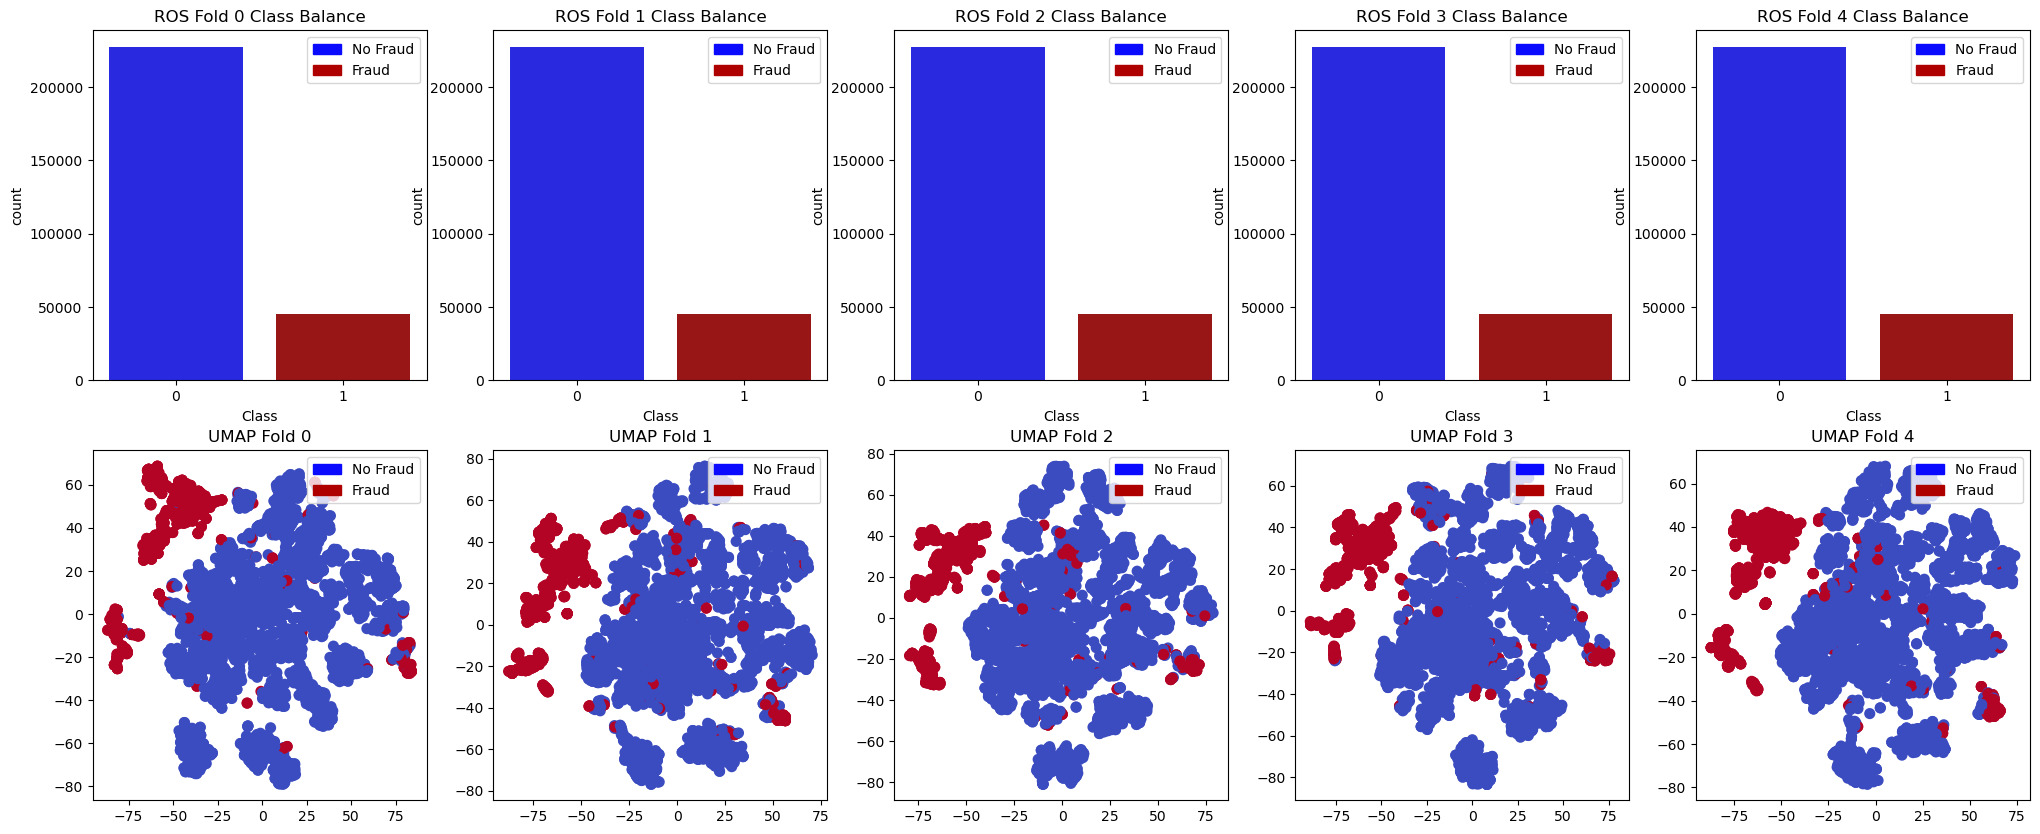

In [ ]:
f, ax = plt.subplots(2, 5, figsize=(25,10))
for i, (X_res, y_res) in enumerate(ros_train):
    sns.countplot(x = y_res, ax = ax[0][i], palette=['#0A0AFF', '#AF0000'], hue = y_res)
    ax[0][i].set_title(f"ROS Fold {i} Class Balance")
    ax[0][i].legend(handles=[blue_patch, red_patch])
    idx = np.random.choice(len(X_res), size=5000, replace=False)
    X_small = X_res.iloc[idx]
    y_small = y_res.iloc[idx]
    X_reduced = TSNE(n_components=2).fit_transform(X_small)
    ax[1][i].scatter(X_reduced[:,0], X_reduced[:,1], c=y_small, cmap='coolwarm', linewidths=2)
    ax[1][i].set_title(f"UMAP Fold {i}")
    ax[1][i].legend(handles=[blue_patch, red_patch], loc = 'upper right')

## 4. SMOTE (Synthetic Minority Over-Sampling)

In [ ]:
smote_train, smote_test = create_resampled_folds(X, y, SMOTE(sampling_strategy=0.2))

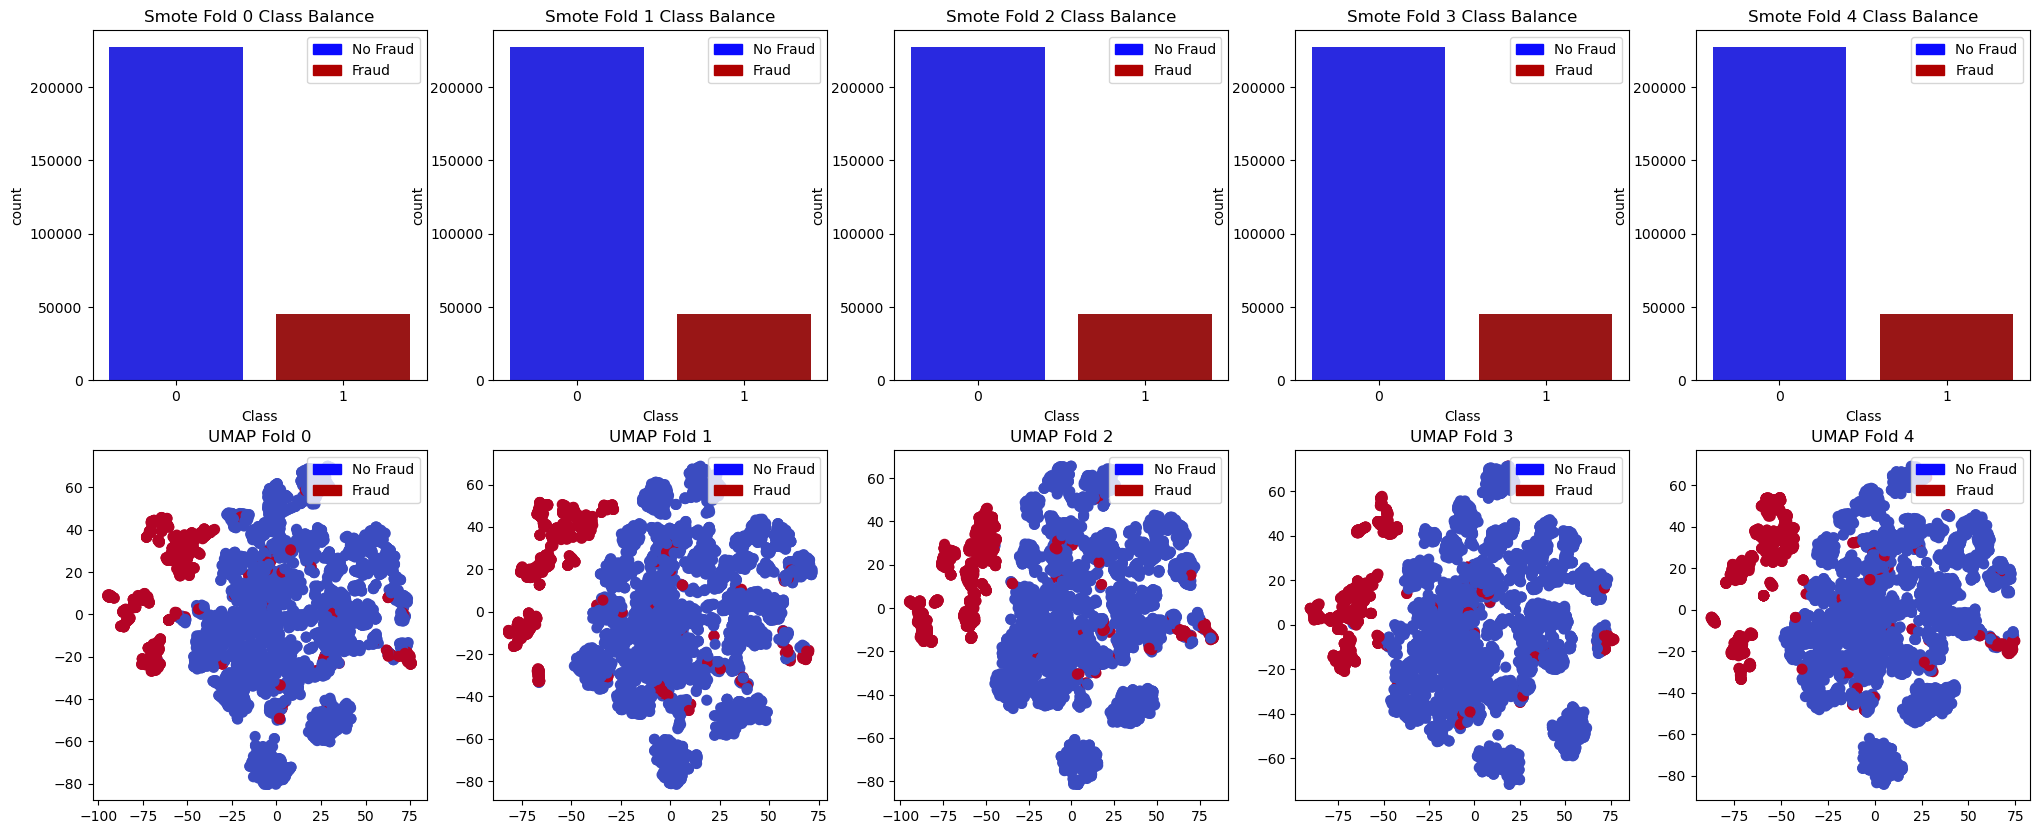

In [ ]:
f, ax = plt.subplots(2, 5, figsize=(25,10))
for i, (X_res, y_res) in enumerate(smote_train):
    sns.countplot(x = y_res, ax = ax[0][i], palette=['#0A0AFF', '#AF0000'], hue = y_res)
    ax[0][i].set_title(f"Smote Fold {i} Class Balance")
    ax[0][i].legend(handles=[blue_patch, red_patch])
    idx = np.random.choice(len(X_res), size=5000, replace=False)
    X_small = X_res.iloc[idx]
    y_small = y_res.iloc[idx]
    X_reduced = TSNE(n_components=2).fit_transform(X_small)
    ax[1][i].scatter(X_reduced[:,0], X_reduced[:,1], c=y_small, cmap='coolwarm', linewidths=2)
    ax[1][i].set_title(f"UMAP Fold {i}")
    ax[1][i].legend(handles=[blue_patch, red_patch], loc = 'upper right')

## 5. Combine Tomek and SMOTE

In [ ]:
smotetomek_train, smotetomek_test = create_resampled_folds(X, y, SMOTETomek(sampling_strategy=0.2))

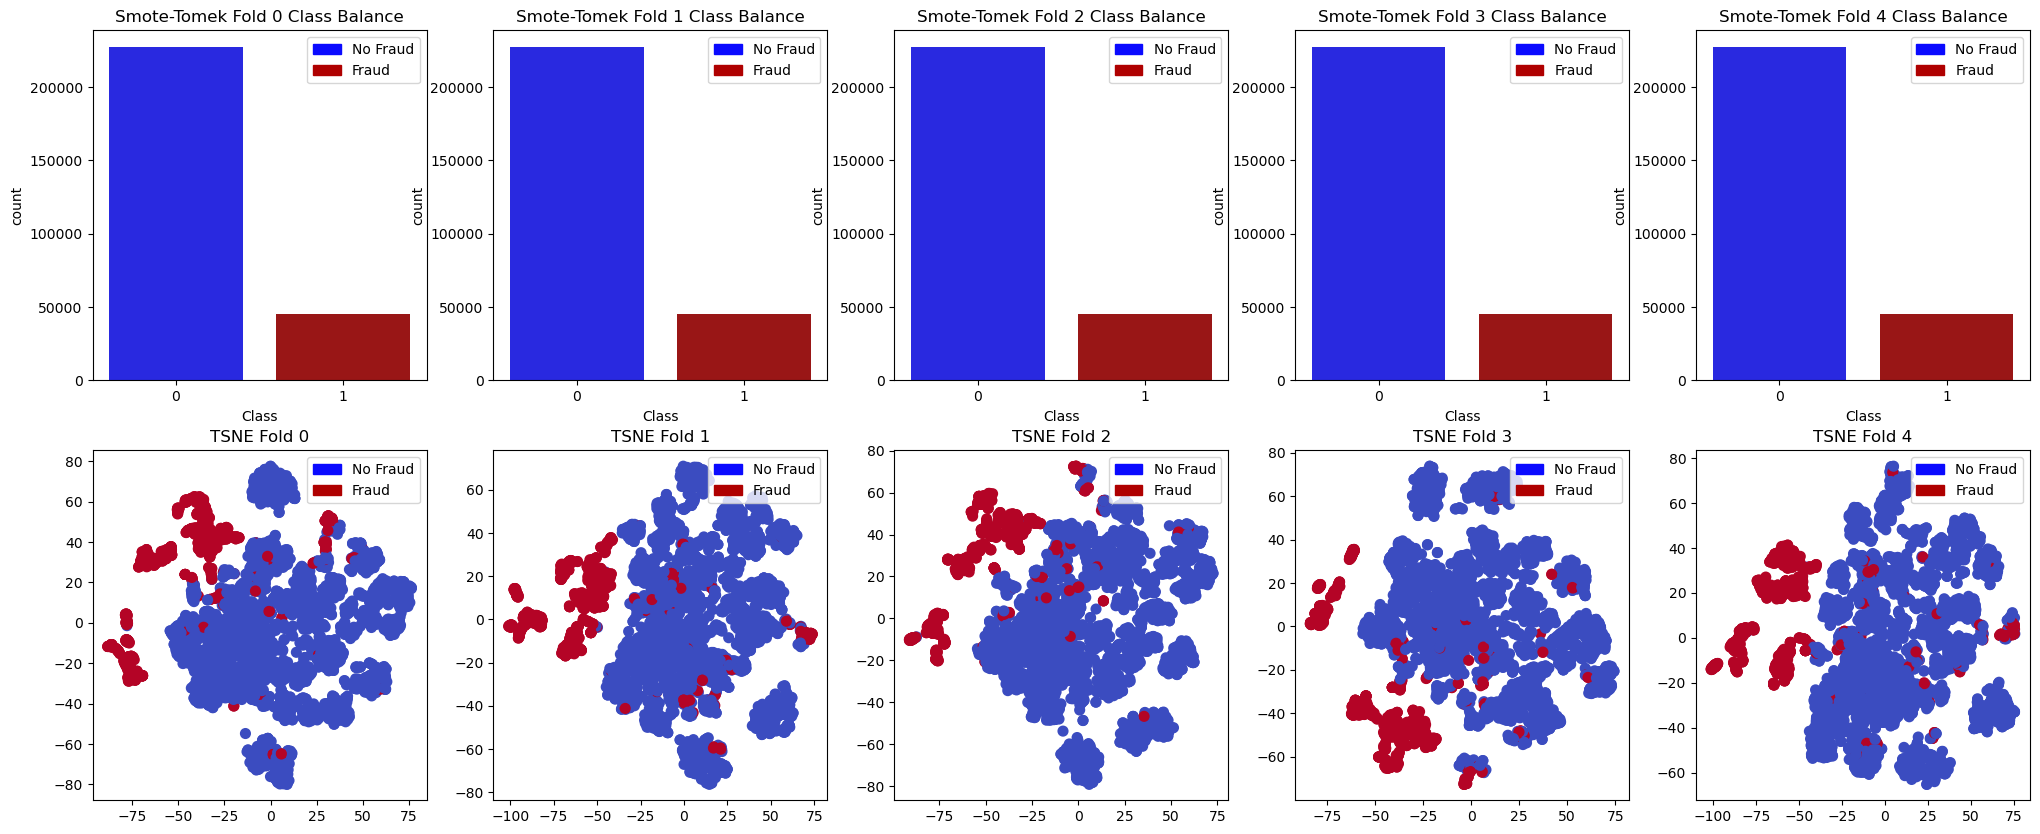

In [ ]:
f, ax = plt.subplots(2, 5, figsize=(25,10))
for i, (X_res, y_res) in enumerate(smotetomek_train):
    sns.countplot(x = y_res, ax = ax[0][i], palette=['#0A0AFF', '#AF0000'], hue = y_res)
    ax[0][i].set_title(f"Smote-Tomek Fold {i} Class Balance")
    ax[0][i].legend(handles=[blue_patch, red_patch])
    idx = np.random.choice(len(X_res), size=5000, replace=False)
    X_small = X_res.iloc[idx]
    y_small = y_res.iloc[idx]
    X_reduced = TSNE(n_components=2).fit_transform(X_small)
    ax[1][i].scatter(X_reduced[:,0], X_reduced[:,1], c=y_small, cmap='coolwarm', linewidths=2)
    ax[1][i].set_title(f"TSNE Fold {i}")
    ax[1][i].legend(handles=[blue_patch, red_patch], loc = 'upper right')

# IV. Training models

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, random_state=42)

## 1. Choosing metrics

In [ ]:
def run_model(model, sampler, param_grid, X_train, X_test, y_train, y_test):
    steps = []
    if sampler is not None:
        steps.append(('sampler', sampler))

    steps.append(('clf', model))

    pipe = Pipeline(steps)

    grid = GridSearchCV(
        estimator=pipe,
        param_grid=param_grid,
        scoring='average_precision',
        n_jobs=-1,
        cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    )

    grid.fit(X_train, y_train)

    print("Best Params:", grid.best_params_)

    best_model = grid.best_estimator_
    y_pred = best_model.predict(X_test)
    
    print("Recall:", recall_score(y_test, y_pred))
    print("Precision:", precision_score(y_test, y_pred))
    print("f1-score: ", f1_score(y_test, y_pred))
    print("\n")

    return {"best_model":best_model, 
            "model_score": grid.best_score_, 
            "best_params":grid.best_params_, 
            "recall_score":recall_score(y_test, y_pred),
            "precision_score":precision_score(y_test, y_pred),
            "f1-score":f1_score(y_test, y_pred)}


## 2. Model comparison

In [ ]:
params_grid_log = {"clf__penalty": ['l1', 'l2'], 
                   'clf__C': [0.001, 0.01, 0.1, 1, 10, 100, 1000]}
logreg = run_model(LogisticRegression(solver= 'liblinear', class_weight='balanced', max_iter=3000), 
                   None, 
                   params_grid_log, X_train, X_test, y_train, y_test)
logreg_rus = run_model(LogisticRegression(solver= 'liblinear', max_iter=3000), 
                       RandomUnderSampler(sampling_strategy=0.5, random_state=42), 
                       params_grid_log, X_train, X_test, y_train, y_test)
logreg_nm = run_model(LogisticRegression(solver= 'liblinear', max_iter=3000), 
                      NearMiss(sampling_strategy=0.5), 
                      params_grid_log, X_train, X_test, y_train, y_test)
logreg_ros = run_model(LogisticRegression(solver= 'liblinear', max_iter=3000), 
                       RandomOverSampler(sampling_strategy=0.2, random_state=42), 
                       params_grid_log, X_train, X_test, y_train, y_test)
logreg_smote = run_model(LogisticRegression(solver= 'liblinear', max_iter=3000), 
                         SMOTE(sampling_strategy=0.2, random_state=42), 
                         params_grid_log, X_train, X_test, y_train, y_test)
logreg_smotetomek = run_model(LogisticRegression(solver= 'liblinear', max_iter=3000), 
                              SMOTETomek(smote=SMOTE(sampling_strategy=0.2, random_state=42), tomek=TomekLinks(sampling_strategy='majority')), 
                              params_grid_log, X_train, X_test, y_train, y_test)

Best Params: {'clf__C': 0.001, 'clf__penalty': 'l2'}
Recall: 0.8861788617886179
Precision: 0.06753407682775713
f1-score:  0.12550374208405296


Best Params: {'clf__C': 1000, 'clf__penalty': 'l2'}
Recall: 0.8943089430894309
Precision: 0.0718954248366013
f1-score:  0.13309134906231096


Best Params: {'clf__C': 100, 'clf__penalty': 'l2'}
Recall: 0.9186991869918699
Precision: 0.003498668648213512
f1-score:  0.006970790536997625


Best Params: {'clf__C': 0.01, 'clf__penalty': 'l2'}
Recall: 0.8536585365853658
Precision: 0.2267818574514039
f1-score:  0.3583617747440273


Best Params: {'clf__C': 0.001, 'clf__penalty': 'l2'}
Recall: 0.8536585365853658
Precision: 0.2328159645232816
f1-score:  0.36585365853658536


Best Params: {'clf__C': 0.001, 'clf__penalty': 'l2'}
Recall: 0.8536585365853658
Precision: 0.2328159645232816
f1-score:  0.36585365853658536




In [ ]:
params_grid_rf = {
    'clf__n_estimators': [100, 200],
    'clf__max_depth':  [6, 12],
    "clf__min_samples_leaf": [50, 100, 200],
}
rf = run_model(RandomForestClassifier(class_weight='balanced', random_state=42), 
               None, 
               params_grid_rf, X_train, X_test, y_train, y_test)
rf_rus = run_model(RandomForestClassifier(random_state=42), 
                   RandomUnderSampler(sampling_strategy=0.5, random_state=42), 
                   params_grid_rf, X_train, X_test, y_train, y_test)
rf_nm = run_model(RandomForestClassifier(random_state=42), 
                  NearMiss(sampling_strategy=0.5), 
                  params_grid_rf, X_train, X_test, y_train, y_test)
rf_ros = run_model(RandomForestClassifier(random_state=42), 
                   RandomOverSampler(sampling_strategy=0.2, random_state=42), 
                   params_grid_rf, X_train, X_test, y_train, y_test)
rf_smote = run_model(RandomForestClassifier(random_state=42), 
                     SMOTE(sampling_strategy=0.2, random_state=42), 
                     params_grid_rf, X_train, X_test, y_train, y_test)
rf_smotetomek = run_model(RandomForestClassifier(random_state=42), 
                          SMOTETomek(smote=SMOTE(sampling_strategy=0.2, random_state=42), tomek=TomekLinks(sampling_strategy='majority')), 
                          params_grid_rf, X_train, X_test, y_train, y_test)

Best Params: {'clf__max_depth': 6, 'clf__min_samples_leaf': 200, 'clf__n_estimators': 100}
Recall: 0.8617886178861789
Precision: 0.3521594684385382
f1-score:  0.5


Best Params: {'clf__max_depth': 6, 'clf__min_samples_leaf': 50, 'clf__n_estimators': 100}
Recall: 0.8536585365853658
Precision: 0.4449152542372881
f1-score:  0.584958217270195


Best Params: {'clf__max_depth': 6, 'clf__min_samples_leaf': 50, 'clf__n_estimators': 100}
Recall: 0.8536585365853658
Precision: 0.011725293132328308
f1-score:  0.023132848645076007


Best Params: {'clf__max_depth': 12, 'clf__min_samples_leaf': 200, 'clf__n_estimators': 200}
Recall: 0.8536585365853658
Precision: 0.5965909090909091
f1-score:  0.7023411371237458


Best Params: {'clf__max_depth': 12, 'clf__min_samples_leaf': 200, 'clf__n_estimators': 200}
Recall: 0.8617886178861789
Precision: 0.5608465608465608
f1-score:  0.6794871794871795


Best Params: {'clf__max_depth': 12, 'clf__min_samples_leaf': 200, 'clf__n_estimators': 200}
Recall: 0.8617886178

In [ ]:
params_grid_sgd = {
    'clf__alpha': [1e-6, 1e-5, 1e-4, 1e-3],
    'clf__penalty': ['l2', 'l1'],
    'clf__loss': ["log_loss"]
}
sgd = run_model(SGDClassifier(max_iter=3000, class_weight='balanced', random_state=42), 
                None, 
                params_grid_sgd, X_train, X_test, y_train, y_test)
sgd_rus = run_model(SGDClassifier(max_iter=3000, random_state=42), 
                    RandomUnderSampler(sampling_strategy=0.5, random_state=42), 
                    params_grid_sgd, X_train, X_test, y_train, y_test)
sgd_nm = run_model(SGDClassifier( max_iter=3000, random_state=42), 
                   NearMiss(sampling_strategy=0.5), 
                   params_grid_sgd, X_train, X_test, y_train, y_test)
sgd_ros = run_model(SGDClassifier(max_iter=3000, random_state=42), 
                    RandomOverSampler(sampling_strategy=0.2, random_state=42), 
                    params_grid_sgd, X_train, X_test, y_train, y_test)
sgd_smote = run_model(SGDClassifier(max_iter=3000, random_state=42), 
                      SMOTE(sampling_strategy=0.2, random_state=42), 
                      params_grid_sgd, X_train, X_test, y_train, y_test)
sgd_smotetomek = run_model(SGDClassifier(max_iter=3000, random_state=42), 
                           SMOTETomek(smote=SMOTE(sampling_strategy=0.2, random_state=42), tomek=TomekLinks(sampling_strategy='majority')), 
                           params_grid_sgd, X_train, X_test, y_train, y_test)

Best Params: {'clf__alpha': 0.001, 'clf__loss': 'log_loss', 'clf__penalty': 'l1'}
Recall: 0.8943089430894309
Precision: 0.04
f1-score:  0.07657500870170554


Best Params: {'clf__alpha': 1e-05, 'clf__loss': 'log_loss', 'clf__penalty': 'l2'}
Recall: 0.8699186991869918
Precision: 0.05211885046273746
f1-score:  0.09834558823529412


Best Params: {'clf__alpha': 1e-05, 'clf__loss': 'log_loss', 'clf__penalty': 'l2'}
Recall: 0.9512195121951219
Precision: 0.00376872282171042
f1-score:  0.007507700205338809


Best Params: {'clf__alpha': 0.001, 'clf__loss': 'log_loss', 'clf__penalty': 'l1'}
Recall: 0.8780487804878049
Precision: 0.13027744270205066
f1-score:  0.226890756302521


Best Params: {'clf__alpha': 0.001, 'clf__loss': 'log_loss', 'clf__penalty': 'l1'}
Recall: 0.8780487804878049
Precision: 0.09863013698630137
f1-score:  0.17733990147783252


Best Params: {'clf__alpha': 0.001, 'clf__loss': 'log_loss', 'clf__penalty': 'l1'}
Recall: 0.8780487804878049
Precision: 0.09863013698630137
f1-score:  

# V. Conclude

## 1. Evaluate model

In [ ]:
def draw_learning_curve(model_name, best_model, X_train, y_train, ax):
    train_sizes, train_scores, val_scores = learning_curve(
        best_model,
        X_train,
        y_train,
        cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
        scoring="average precision",
        n_jobs=-1,
        train_sizes=np.linspace(0.1, 1.0, 5)
    )
    ax.plot(train_sizes, train_scores.mean(axis=1), label="Train Recall")
    ax.plot(train_sizes, val_scores.mean(axis=1), label="Validation Recall")
    ax.set_xlabel("Training Set Size")
    ax.set_ylabel("Recall")
    ax.set_title(f"Learning Curve of {model_name}")
    ax.legend()

In [ ]:
def draw_confusion_matrix(model_name, best_model, X_train, X_test, y_train, y_test, ax):
    best_model.fit(X_train, y_train)
    y_pred = best_model.predict_proba(X_test)[:, 1]

    ConfusionMatrixDisplay.from_predictions(
        y_test,
        y_pred,
        ax=ax,
        cmap="Blues",
        colorbar=False
    )

    ax.set_title(f"Confusion Matrix – {model_name}")

In [ ]:
def draw_precision_recall_curve(model_name, best_model, X_train, X_test, y_train, y_test, ax):
    
    best_model.fit(X_train, y_train)
    y_pred = best_model.predict_proba(X_test)[:, 1]

    PrecisionRecallDisplay.from_predictions(
        y_test,
        y_pred,
        ax=ax
    )

    ax.set_title(f"Precision–Recall Curve – {model_name}")

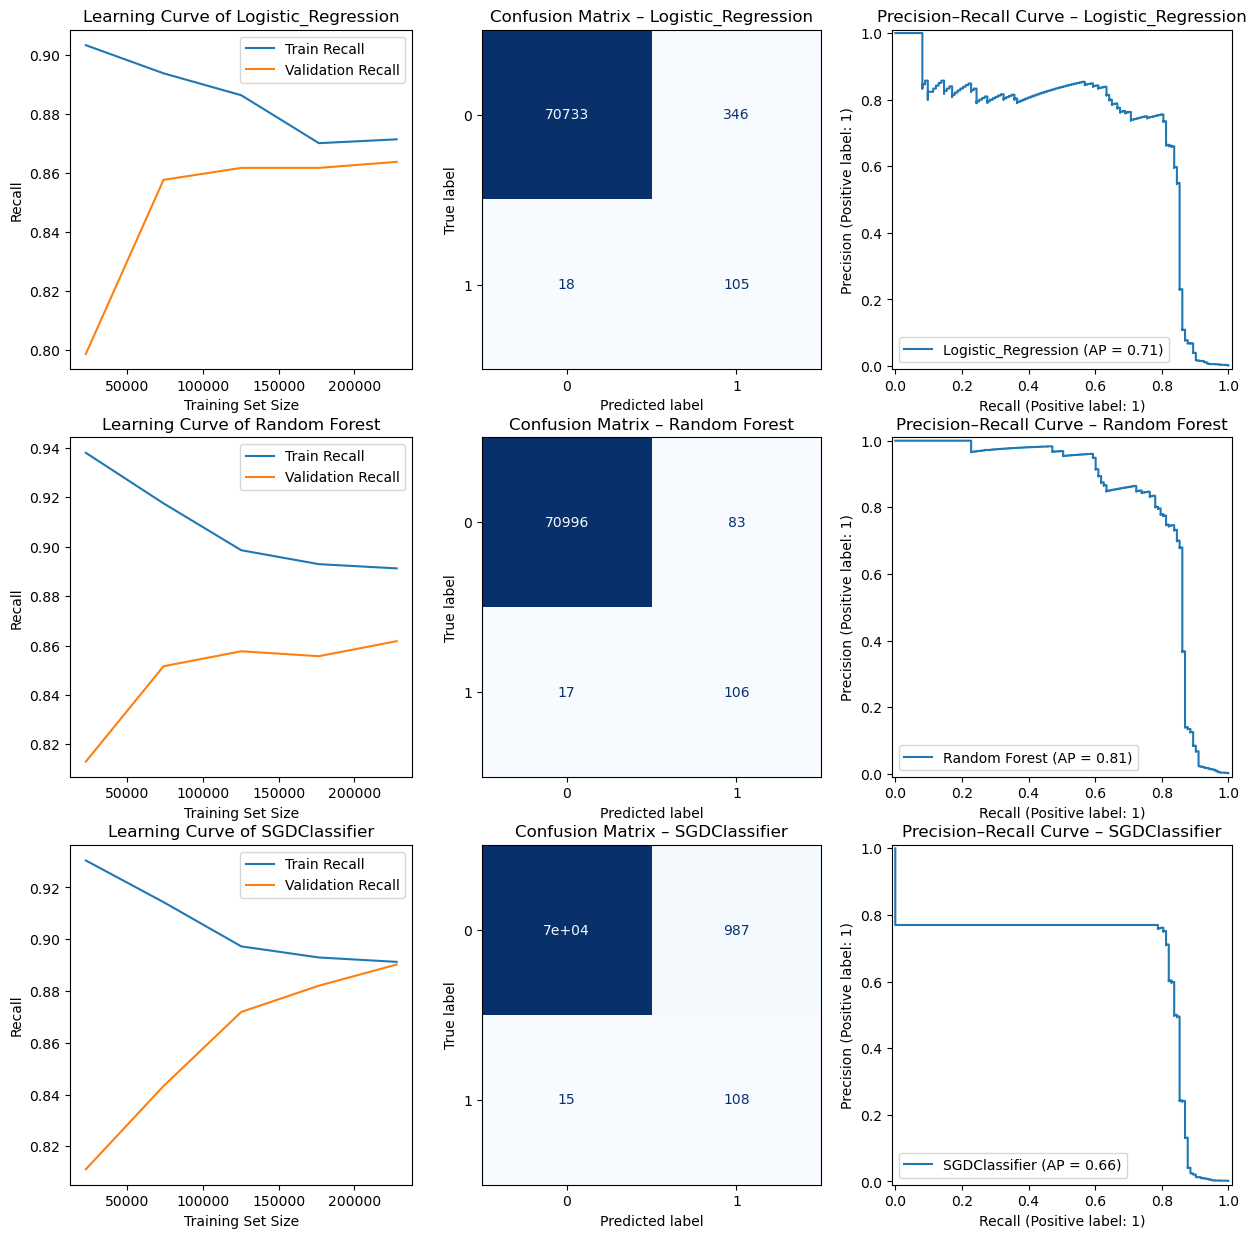

In [ ]:
models = {
    "Logistic_Regression": logreg_smotetomek["best_model"],
    "Random Forest": rf_smotetomek["best_model"],
    "SGDClassifier": sgd_smotetomek["best_model"]
}
fig, ax = plt.subplots(3, 3, figsize = (15, 15))
ax = ax.flatten()
i = 0
for model_name, best_model in models.items():
    draw_learning_curve(model_name, best_model, X_train, y_train, ax[i])
    draw_confusion_matrix(model_name, best_model, X_train, X_test, y_train, y_test, ax[i+1])
    draw_precision_recall_curve(model_name, best_model, X_train, X_test, y_train, y_test, ax[i+2])
    i += 3


## 2. Threshold tunning

In [ ]:
def predict_with_threshold(model, X, threshold):
    original_prob = model.predict_proba(X)[:, 1]
    threshold_classify = (original_prob >= original_prob).astype(int)
    y_pred = threshold_classify.astype(int)
    return y_pred

def evaluate_threshold(model, X_test, y_test, threshold):
    y_pred = predict_with_threshold(model, X_test, threshold)
    
    return {
        "threshold": threshold,
        "recall": recall_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred),
        "f1": f1_score(y_test, y_pred),
        "confusion_matrix": confusion_matrix(y_test, y_pred)
    }

def threshold_curve(model, X_test, y_test, thresholds=np.linspace(0.1, 0.9, 9)):
    results = []
    
    for t in thresholds:
        res = evaluate_threshold(model, X_test, y_test, t)
        results.append(res)
    
    return results

{'threshold': 0.1, 'recall': 0.9105691056910569, 'precision': 0.035908945174735495, 'f1': 0.06909315237507711, 'confusion_matrix': array([[68072,  3007],
       [   11,   112]], dtype=int64)}
{'threshold': 0.2, 'recall': 0.8943089430894309, 'precision': 0.12154696132596685, 'f1': 0.2140077821011673, 'confusion_matrix': array([[70284,   795],
       [   13,   110]], dtype=int64)}
{'threshold': 0.30000000000000004, 'recall': 0.8699186991869918, 'precision': 0.26354679802955666, 'f1': 0.4045368620037807, 'confusion_matrix': array([[70780,   299],
       [   16,   107]], dtype=int64)}
{'threshold': 0.4, 'recall': 0.8617886178861789, 'precision': 0.43983402489626555, 'f1': 0.5824175824175825, 'confusion_matrix': array([[70944,   135],
       [   17,   106]], dtype=int64)}
{'threshold': 0.5, 'recall': 0.8617886178861789, 'precision': 0.5608465608465608, 'f1': 0.6794871794871795, 'confusion_matrix': array([[70996,    83],
       [   17,   106]], dtype=int64)}
{'threshold': 0.6, 'recall': 0.85

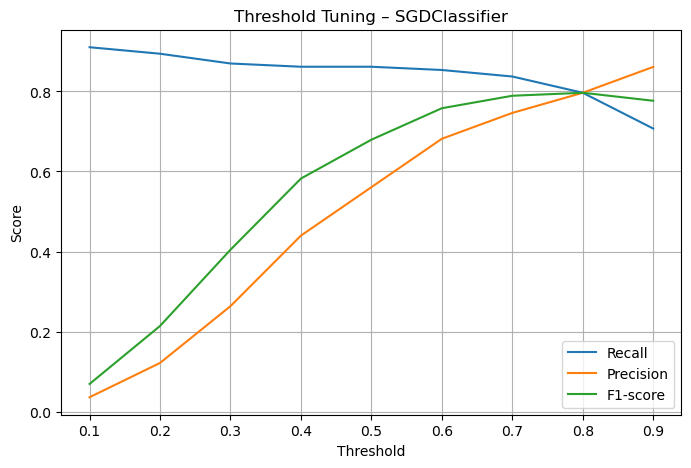

In [ ]:
best_model = rf_smotetomek["best_model"]
results = threshold_curve(
    model=best_model,
    X_test=X_test,
    y_test=y_test
)

for r in results:
    print(r)

thresholds = [r["threshold"] for r in results]
recalls = [r["recall"] for r in results]
precisions = [r["precision"] for r in results]
f1s = [r["f1"] for r in results]

plt.figure(figsize=(8,5))
plt.plot(thresholds, recalls, label="Recall")
plt.plot(thresholds, precisions, label="Precision")
plt.plot(thresholds, f1s, label="F1-score")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Threshold Tuning")
plt.legend()
plt.grid(True)
plt.show()

# VI. References
- Janio Martinez Bachmann. (2019). Credit Fraud || Dealing with Imbalanced Datasets: https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud
- Gabriel Preda. (2021). Credit Card Fraud Detection Predictive Models: https://www.kaggle.com/code/gpreda/credit-card-fraud-detection-predictive-models